<a href="https://colab.research.google.com/github/kavenlankalapalli/Capstone-DR/blob/main/DREfficientNetB3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ==========================================================
# EfficientNetB3 @ 300x300 — fine-tuning script
# ==========================================================

import os, tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

In [3]:
# ---------------------
# step -0) CONFIG
# ---------------------
SEED = 42
IMG_SIZE = (300, 300)         # B3 native resolution
BATCH = 32
DROPOUT = 0.3
EPOCHS_WARMUP = 3             # train head only
EPOCHS_FT = 20                # fine-tune backbone
INITIAL_LR_WARMUP = 1e-3
INITIAL_LR_FT = 1e-4
VAL_MONITOR = "val_auc"       # or "val_loss"
MODEL_OUT = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras"

TRAIN_DIR = os.path.expanduser("/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/train")
VAL_DIR = os.path.expanduser("/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation")
tf.random.set_seed(SEED)


In [4]:
# ---------------------
# Step - 1) DATA
# ---------------------
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)

CLASS_NAMES = train_ds.class_names  # e.g., ['0','1','2','3','4']
NUM_CLASSES = len(CLASS_NAMES)

def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.08)
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    return x, y

train_ds = train_ds.map(augment, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

Found 2929 files belonging to 5 classes.
Found 733 files belonging to 5 classes.


In [7]:
# ---------------------
# Step -2) MODEL (B3 from ImageNet)
# ---------------------
def build_b3(num_classes: int, dropout: float = DROPOUT):
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    # Keep rescaling explicit for portability across TF versions
    x = layers.Rescaling(1./255)(inputs)
    base = EfficientNetB3(include_top=False, weights="imagenet", input_tensor=x)
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = models.Model(inputs, outputs, name="efficientnetb3_300")
    return model, base

model, base = build_b3(NUM_CLASSES)

# Metrics
auc   = tf.keras.metrics.AUC(name="auc",   multi_label=True, num_labels=NUM_CLASSES, curve="ROC")
auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=NUM_CLASSES, curve="PR")
#model.summary()


In [8]:
# ---------------------
# Step -3 WARM-UP (head only)
# ---------------------
for l in base.layers:
    l.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(INITIAL_LR_WARMUP),
    loss="categorical_crossentropy",
    metrics=["accuracy", auc, auprc],
)

callbacks_warm = [
    ModelCheckpoint("b3_300_warmup.keras", monitor=VAL_MONITOR, mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor=VAL_MONITOR, mode="max", patience=2, restore_best_weights=True, verbose=1),
]

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_WARMUP,
    callbacks=callbacks_warm,
    verbose=1,
)


Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4911 - auc: 0.4884 - auprc: 0.2011 - loss: 1.3447
Epoch 1: val_auc improved from -inf to 0.62941, saving model to b3_300_warmup.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.4911 - auc: 0.4885 - auprc: 0.2011 - loss: 1.3445 - val_accuracy: 0.4925 - val_auc: 0.6294 - val_auprc: 0.2951 - val_loss: 1.3246
Epoch 2/3
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4888 - auc: 0.4992 - auprc: 0.2103 - loss: 1.3131
Epoch 2: val_auc improved from 0.62941 to 0.65132, saving model to b3_300_warmup.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.4887 - auc: 0.4993 - auprc: 0.2102 - loss: 1.3130 - val_accuracy: 0.4925 - val_auc: 0.6513 - val_auprc: 0.3138 - val_loss: 1.3225
Epoch 3/3
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4907 - auc: 0.5033 - auprc: 0.2075 - loss: 1.3137
Epoch 3: val_auc improved from 0.65132 to 0.66761, saving model to b3_300_warmup.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101

In [9]:
# ---------------------
# 4) FINE-TUNE (unfreeze top ~50% + Cosine LR)
# ---------------------
# Keeping BatchNorm frozen for stability
for l in base.layers:
    if isinstance(l, tf.keras.layers.BatchNormalization):
        l.trainable = False

# Unfreeze top half (adjust fraction as desired)
unfreeze_from = len(base.layers) // 2
for i, l in enumerate(base.layers):
    if i >= unfreeze_from and not isinstance(l, tf.keras.layers.BatchNormalization):
        l.trainable = True

# Cosine Decay Restarts schedule (step-based)
steps_per_epoch = int(tf.data.experimental.cardinality(train_ds).numpy())
first_decay_steps = steps_per_epoch * 5  # ~5 epochs per cycle initially
lr_schedule = CosineDecayRestarts(
    initial_learning_rate=INITIAL_LR_FT,
    first_decay_steps=first_decay_steps,
    t_mul=2.0, m_mul=0.9, alpha=1e-6
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr_schedule),
    loss="categorical_crossentropy",
    metrics=["accuracy", auc, auprc],
)

callbacks_ft = [
    ModelCheckpoint(MODEL_OUT, monitor=VAL_MONITOR, mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor=VAL_MONITOR, mode="max", patience=5, restore_best_weights=True, verbose=1),
]

model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft,
    verbose=1,
)

print(f" Saved EfficientNetB3 (300×300) to: {MODEL_OUT}")

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 474ms/step - accuracy: 0.4728 - auc: 0.5358 - auprc: 0.2193 - loss: 1.3279
Epoch 1: val_auc improved from -inf to 0.53073, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 122s 716ms/step - accuracy: 0.4729 - auc: 0.5355 - auprc: 0.2192 - loss: 1.3277 - val_accuracy: 0.4925 - val_auc: 0.5307 - val_auprc: 0.2266 - val_loss: 1.3017
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4894 - auc: 0.5031 - auprc: 0.2041 - loss: 1.3089
Epoch 2: val_auc improved from 0.53073 to 0.59433, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.4894 - auc: 0.5032 - auprc: 0.2041 - loss: 1.3088 - val_accuracy: 0.4925 - val_auc: 0.5943 - val_auprc: 0.2732 - val_loss: 1.3061
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 

Found 733 files belonging to 5 classes.
=== Classification Report ===
              precision    recall  f1-score   support

           0      0.854     0.889     0.871       361
           1      0.000     0.000     0.000        74
           2      0.499     0.890     0.639       200
           3      0.000     0.000     0.000        39
           4      0.000     0.000     0.000        59

    accuracy                          0.681       733
   macro avg      0.270     0.356     0.302       733
weighted avg      0.556     0.681     0.603       733



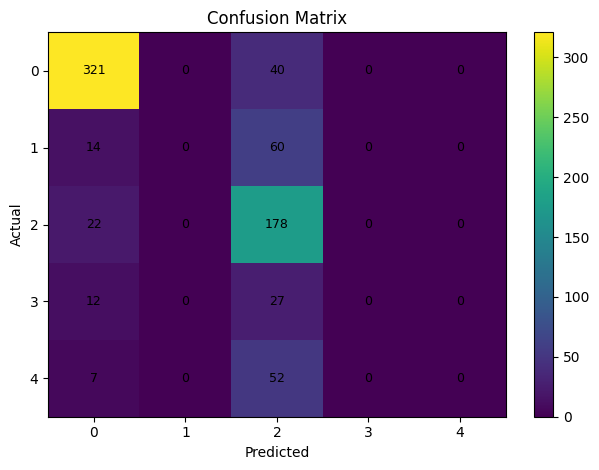

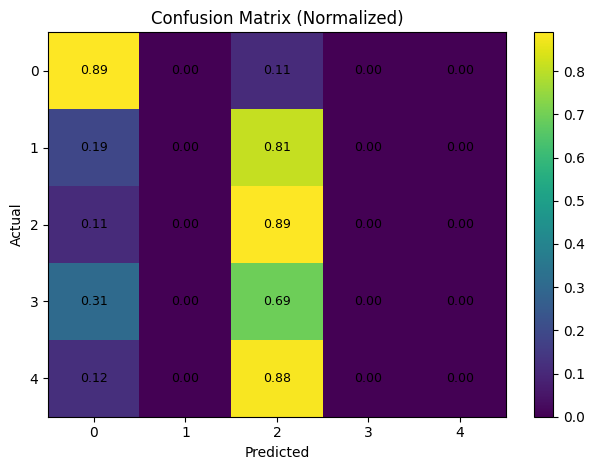

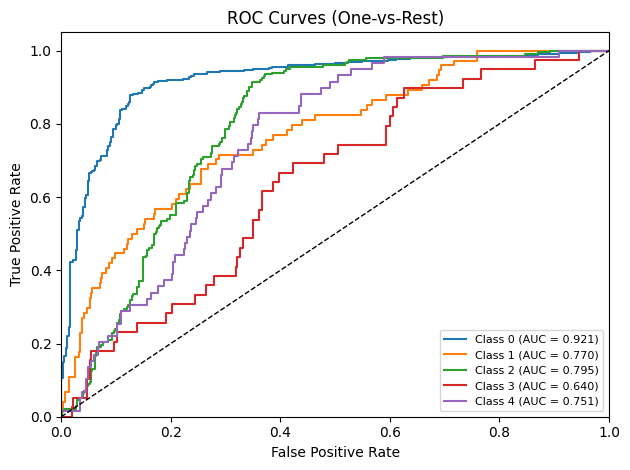

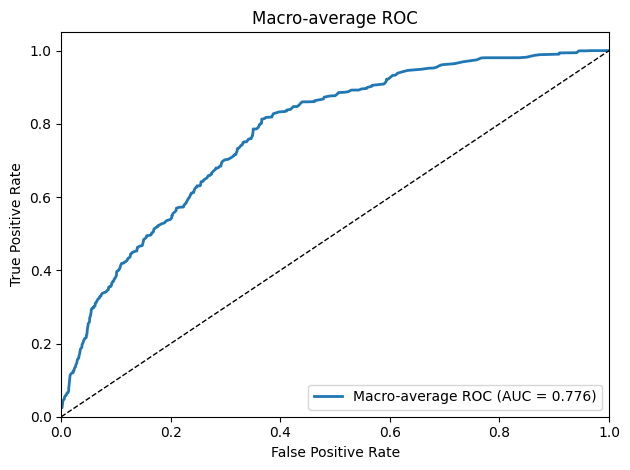

In [11]:
# ==========================================
# Evaluate B3@300: CM, Classification Report, ROC AUC
# ==========================================

import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -------- CONFIG (edit these) --------
MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras"   # your improved model
VAL_DIR    = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"                    # folder with subfolders 0..4
IMG_SIZE   = (300, 300)                             # B3 input size
BATCH      = 32

# -------- Data --------
# Create first, capture class names, THEN cache/prefetch
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)
CLASS_NAMES = val_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

val_ds = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)

# -------- Load model --------
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# -------- Predict helper --------
def get_truth_and_preds(model, dataset):
    y_true, y_proba = [], []
    for x, y in dataset:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_proba.append(p)
    y_true  = np.vstack(y_true)                 # one-hot
    y_proba = np.vstack(y_proba)               # probabilities (softmax)
    y_true_int = np.argmax(y_true, axis=1)     # integer labels
    y_pred_int = np.argmax(y_proba, axis=1)    # predicted labels
    return y_true_int, y_pred_int, y_proba

y_true, y_pred, y_proba = get_truth_and_preds(model, val_ds)

# -------- Classification report (printed) --------
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

# -------- Confusion Matrix (plot) --------
def plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    plt.figure()
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    # annotations
    fmt = ".2f" if normalize else "d"
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center", fontsize=9)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plot_confusion_matrix(cm, CLASS_NAMES, normalize=False, title="Confusion Matrix")
plot_confusion_matrix(cm, CLASS_NAMES, normalize=True,  title="Confusion Matrix (Normalized)")

# -------- ROC AUC (one-vs-rest) --------
# Binarize true labels for OvR ROC
Y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))  # shape: [N, C]

# Per-class ROC + AUC
plt.figure()
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {CLASS_NAMES[c]} (AUC = {roc_auc:.3f})")
# Chance line
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Macro-average ROC (optional, nice summary line)
# Combine all FPR points across classes and interpolate TPRs to compute macro curve
all_fpr = np.unique(np.concatenate([roc_curve(Y_bin[:, c], y_proba[:, c])[0] for c in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Macro-average ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Class imbalance mitigation

In [14]:
import os
from collections import Counter

TRAIN_DIR = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/train"
CLASS_NAMES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES = len(CLASS_NAMES)

# Count images per class
counts = {int(c): len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in CLASS_NAMES}
total = sum(counts.values())
# Inverse-frequency weights
class_weight = {c: total / (NUM_CLASSES * n) for c, n in counts.items()}
print("Class counts:", counts)
print("Class weights:", class_weight)


Class counts: {0: 1444, 1: 296, 2: 799, 3: 154, 4: 236}
Class weights: {0: 0.4056786703601108, 1: 1.979054054054054, 2: 0.7331664580725907, 3: 3.803896103896104, 4: 2.4822033898305085}


In [16]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

# Paths
FT1_MODEL = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras"    # from your Iteration 1
CW_MODEL  = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted.keras"

# Data @ 300x300
IMG_SIZE = (300, 300); BATCH = 32
AUTOTUNE = tf.data.AUTOTUNE
TRAIN_DIR = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/train"
VAL_DIR   = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=True
).cache().prefetch(AUTOTUNE)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
).cache().prefetch(AUTOTUNE)

# Load Iteration-1
model = tf.keras.models.load_model(FT1_MODEL, compile=False)

# (Recommended) keep BatchNorm layers frozen for stability
for l in model.layers:
    if isinstance(l, tf.keras.layers.BatchNormalization):
        l.trainable = False

# Small cosine LR for a short imbalance-focused fine-tune
steps = int(tf.data.experimental.cardinality(train_ds).numpy())
lr = CosineDecayRestarts(initial_learning_rate=5e-5, first_decay_steps=steps*4, t_mul=2.0, m_mul=0.9, alpha=1e-6)

auc   = tf.keras.metrics.AUC(name="auc",   multi_label=True, num_labels=NUM_CLASSES, curve="ROC")
auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=NUM_CLASSES, curve="PR")

model.compile(optimizer=tf.keras.optimizers.Adam(lr),
              loss="categorical_crossentropy",
              metrics=["accuracy", auc, auprc])

#callbacks = [
 #   ModelCheckpoint(CW_MODEL, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
  #  EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1),
 #   ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
#]

callbacks = [
    ModelCheckpoint(CW_MODEL, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1),
]

history_cw = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=callbacks,
    class_weight=class_weight,     # <-- the key line
    verbose=1,
)
print(f"Saved class-weighted model to: {CW_MODEL}")

Found 2929 files belonging to 5 classes.
Found 733 files belonging to 5 classes.
Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.4236 - auc: 0.6457 - auprc: 0.2880 - loss: 1.5992
Epoch 1: val_auc improved from -inf to 0.59725, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 136s 875ms/step - accuracy: 0.4239 - auc: 0.6461 - auprc: 0.2882 - loss: 1.5982 - val_accuracy: 0.2988 - val_auc: 0.5972 - val_auprc: 0.2625 - val_loss: 1.6869
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4581 - auc: 0.7121 - auprc: 0.3271 - loss: 1.4896
Epoch 2: val_auc improved from 0.59725 to 0.59830, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - accuracy: 0.4582 - auc: 0.7121 - auprc: 0.3271 - loss: 1.4892 - val_accuracy: 0.2660 - val_auc: 0.5

Found 733 files belonging to 5 classes.
=== Classification Report ===
              precision    recall  f1-score   support

           0      0.952     0.330     0.490       361
           1      0.172     0.797     0.282        74
           2      0.000     0.000     0.000       200
           3      0.015     0.051     0.023        39
           4      0.061     0.136     0.084        59

    accuracy                          0.256       733
   macro avg      0.240     0.263     0.176       733
weighted avg      0.492     0.256     0.278       733



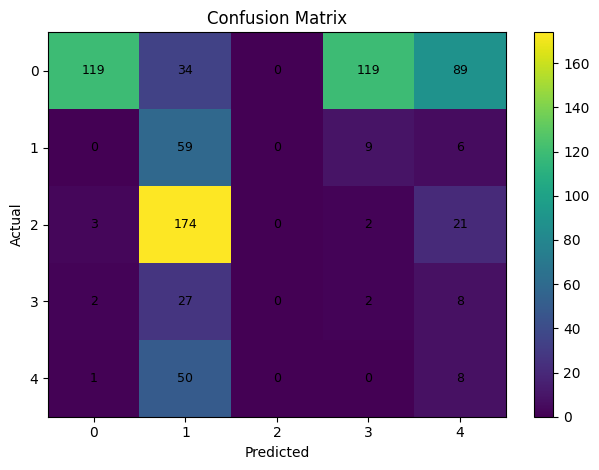

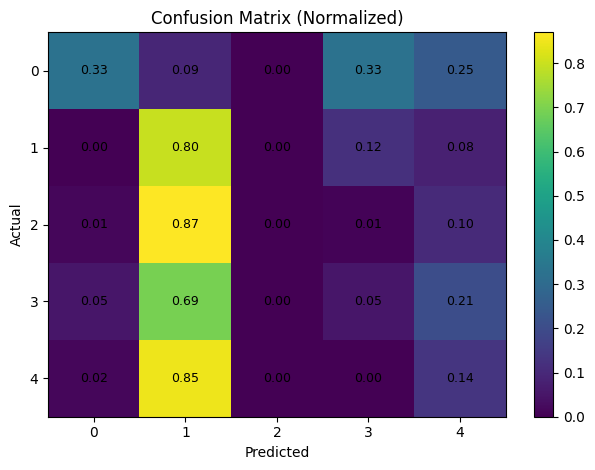

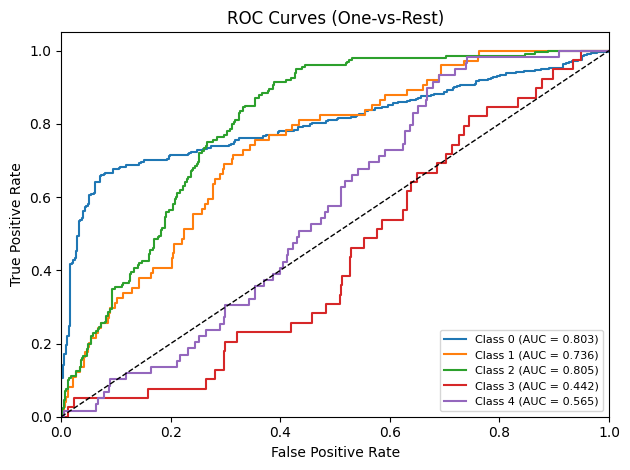

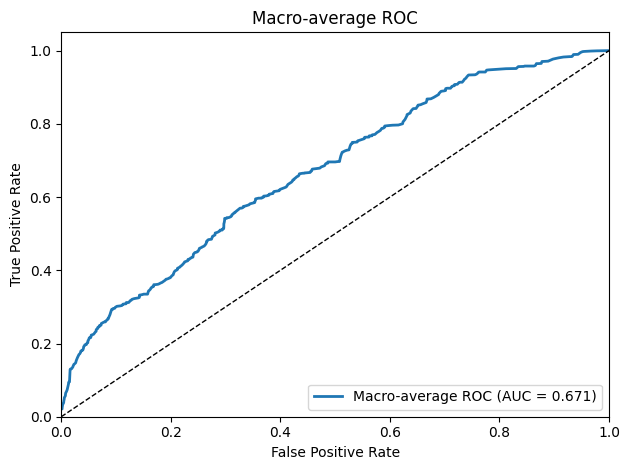

In [17]:
# ==========================================
# Evaluate B3@300: CM, Classification Report, ROC AUC
# ==========================================

import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -------- CONFIG (edit these) --------
MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted.keras"   #  improved model
VAL_DIR    = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"                    # folder with subfolders 0..4
IMG_SIZE   = (300, 300)                             # B3 input size
BATCH      = 32

# -------- Data --------
# Create first, capture class names, THEN cache/prefetch
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)
CLASS_NAMES = val_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

val_ds = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)

# -------- Load model --------
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# -------- Predict helper --------
def get_truth_and_preds(model, dataset):
    y_true, y_proba = [], []
    for x, y in dataset:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_proba.append(p)
    y_true  = np.vstack(y_true)                 # one-hot
    y_proba = np.vstack(y_proba)               # probabilities (softmax)
    y_true_int = np.argmax(y_true, axis=1)     # integer labels
    y_pred_int = np.argmax(y_proba, axis=1)    # predicted labels
    return y_true_int, y_pred_int, y_proba

y_true, y_pred, y_proba = get_truth_and_preds(model, val_ds)

# -------- Classification report (printed) --------
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

# -------- Confusion Matrix (plot) --------
def plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    plt.figure()
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    # annotations
    fmt = ".2f" if normalize else "d"
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center", fontsize=9)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plot_confusion_matrix(cm, CLASS_NAMES, normalize=False, title="Confusion Matrix")
plot_confusion_matrix(cm, CLASS_NAMES, normalize=True,  title="Confusion Matrix (Normalized)")

# -------- ROC AUC (one-vs-rest) --------
# Binarize true labels for OvR ROC
Y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))  # shape: [N, C]

# Per-class ROC + AUC
plt.figure()
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {CLASS_NAMES[c]} (AUC = {roc_auc:.3f})")
# Chance line
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Macro-average ROC (optional, nice summary line)
# Combine all FPR points across classes and interpolate TPRs to compute macro curve
all_fpr = np.unique(np.concatenate([roc_curve(Y_bin[:, c], y_proba[:, c])[0] for c in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Macro-average ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

There is no such imporvement so moving using tempered class weights

In [18]:
import os, numpy as np


TRAIN_DIR = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/train"
VAL_DIR   = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"
counts = {int(c): len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in ['0','1','2','3','4']}
beta = 0.999  # 0.99–0.9999; higher -> closer to inverse freq, lower -> gentler
def eff_num(n): return (1 - beta**n) / (1 - beta)
weights = {c: 1.0 / eff_num(n) for c, n in counts.items()}

# normalize so mean weight ≈ 1.0 (keeps loss scale stable)
mean_w = np.mean(list(weights.values()))
class_weight = {c: w/mean_w for c, w in weights.items()}
print("Class counts:", counts)
print("Tempered class weights:", class_weight)

Class counts: {0: 1444, 1: 296, 2: 799, 3: 154, 4: 236}
Tempered class weights: {0: np.float64(0.3483096802274156), 1: np.float64(1.0384340921621782), 2: np.float64(0.4836003687968964), 3: np.float64(1.864043251418388), 4: np.float64(1.2656126073951217)}


In [20]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
FT1_MODEL = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras"    # from your Iteration 1
CW_MODEL  = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted1.keras"

model = tf.keras.models.load_model(FT1_MODEL, compile=False)

# keep BatchNorm frozen for stability
for l in model.layers:
    if isinstance(l, tf.keras.layers.BatchNormalization):
        l.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.AUC(name="auc", multi_label=True, num_labels=5, curve="ROC"),
             tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=5, curve="PR")]
)

callbacks = [
    ModelCheckpoint(CW_MODEL, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1),
]

model.fit(train_ds, validation_data=val_ds, epochs=12, callbacks=callbacks,
          class_weight=class_weight, verbose=1)


Epoch 1/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.4772 - auc: 0.6377 - auprc: 0.2880 - loss: 0.9385
Epoch 1: val_auc improved from -inf to 0.71015, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted1.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 112s 662ms/step - accuracy: 0.4777 - auc: 0.6381 - auprc: 0.2882 - loss: 0.9380 - val_accuracy: 0.5334 - val_auc: 0.7102 - val_auprc: 0.3469 - val_loss: 1.3036
Epoch 2/12
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5523 - auc: 0.7111 - auprc: 0.3302 - loss: 0.8770
Epoch 2: val_auc improved from 0.71015 to 0.75789, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted1.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - accuracy: 0.5524 - auc: 0.7111 - auprc: 0.3302 - loss: 0.8768 - val_accuracy: 0.6357 - val_auc: 0.7579 - val_auprc: 0.3659 - val_loss: 1.1678
Epoch 3/12
92/92 ━━━━━━━━━━━━━━━━━━━

Found 733 files belonging to 5 classes.
=== Classification Report ===
              precision    recall  f1-score   support

           0      0.890     0.762     0.821       361
           1      0.000     0.000     0.000        74
           2      0.450     0.955     0.612       200
           3      0.000     0.000     0.000        39
           4      0.000     0.000     0.000        59

    accuracy                          0.636       733
   macro avg      0.268     0.343     0.287       733
weighted avg      0.561     0.636     0.571       733



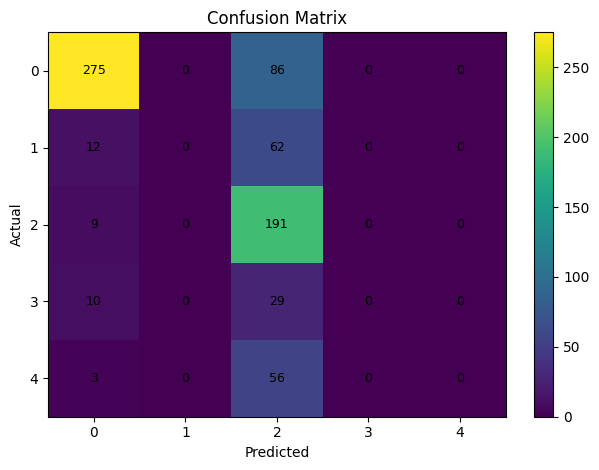

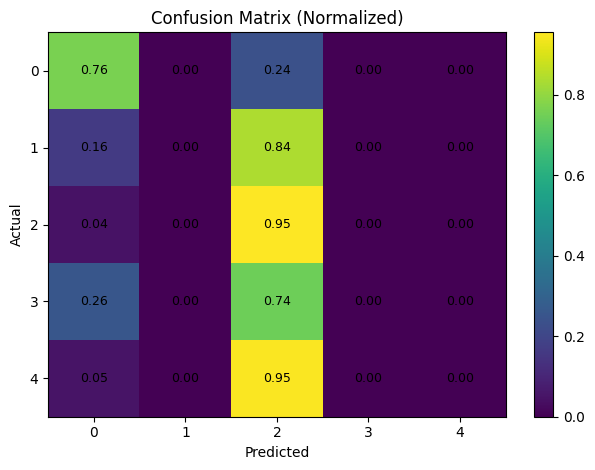

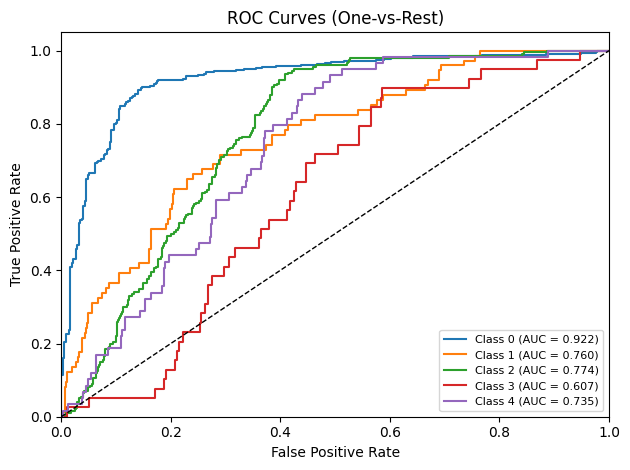

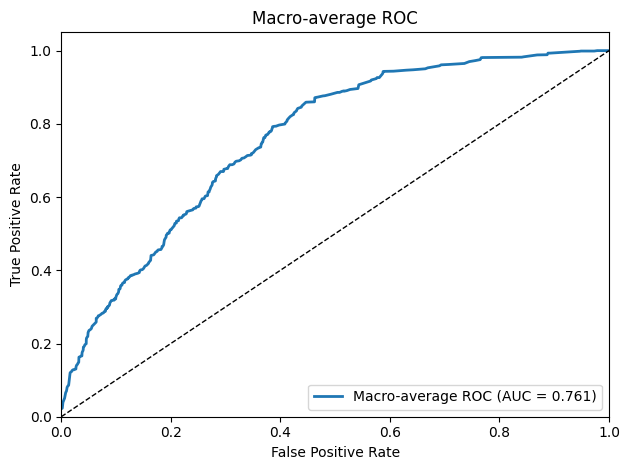

In [22]:
 # ==========================================
# Evaluate B3@300: CM, Classification Report, ROC AUC
# ==========================================

import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -------- CONFIG (edit these) --------
MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_classweighted1.keras"   #  improved model
VAL_DIR    = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"                    # folder with subfolders 0..4
IMG_SIZE   = (300, 300)                             # B3 input size
BATCH      = 32

# -------- Data --------
# Create first, capture class names, THEN cache/prefetch
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)
CLASS_NAMES = val_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

val_ds = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)

# -------- Load model --------
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# -------- Predict helper --------
def get_truth_and_preds(model, dataset):
    y_true, y_proba = [], []
    for x, y in dataset:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_proba.append(p)
    y_true  = np.vstack(y_true)                 # one-hot
    y_proba = np.vstack(y_proba)               # probabilities (softmax)
    y_true_int = np.argmax(y_true, axis=1)     # integer labels
    y_pred_int = np.argmax(y_proba, axis=1)    # predicted labels
    return y_true_int, y_pred_int, y_proba

y_true, y_pred, y_proba = get_truth_and_preds(model, val_ds)

# -------- Classification report (printed) --------
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

# -------- Confusion Matrix (plot) --------
def plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    plt.figure()
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    # annotations
    fmt = ".2f" if normalize else "d"
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center", fontsize=9)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plot_confusion_matrix(cm, CLASS_NAMES, normalize=False, title="Confusion Matrix")
plot_confusion_matrix(cm, CLASS_NAMES, normalize=True,  title="Confusion Matrix (Normalized)")

# -------- ROC AUC (one-vs-rest) --------
# Binarize true labels for OvR ROC
Y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))  # shape: [N, C]

# Per-class ROC + AUC
plt.figure()
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {CLASS_NAMES[c]} (AUC = {roc_auc:.3f})")
# Chance line
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Macro-average ROC (optional, nice summary line)
# Combine all FPR points across classes and interpolate TPRs to compute macro curve
all_fpr = np.unique(np.concatenate([roc_curve(Y_bin[:, c], y_proba[:, c])[0] for c in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Macro-average ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (300, 300)

# Strong, but safe, augmentations
augmenter = tf.keras.Sequential([
    layers.RandomFlip(mode="horizontal_and_vertical"),
    layers.RandomRotation(factor=0.15),
    layers.RandomZoom(height_factor=0.15, width_factor=0.15),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    layers.RandomBrightness(factor=0.15),
    layers.RandomContrast(factor=0.2),
], name="augmenter")

In [24]:
import tensorflow as tf
import tensorflow.keras.backend as K
import tensorflow as tf
import numpy as np

def mixup(ds, alpha=0.2, num_classes=5):
    def _mix(a, b):
        images, labels = a
        images2, labels2 = b
        lam = np.random.beta(alpha, alpha)
        images = lam*images + (1-lam)*images2
        labels = lam*labels + (1-lam)*labels2
        return images, labels
    ds1 = ds.unbatch().batch(1)
    ds2 = ds1.shuffle(2048)
    ds = tf.data.Dataset.zip((ds1, ds2)).map(_mix, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.unbatch().batch(BATCH).prefetch(tf.data.AUTOTUNE)

In [25]:
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import models

NUM_CLASSES = 5   # ['0','1','2','3','4']
BATCH = 32

def build_b3_with_aug(num_classes=NUM_CLASSES, dropout=0.4):
    inputs = layers.Input(IMG_SIZE + (3,))
    x = layers.Rescaling(1./255)(inputs)
    x = augmenter(x)                    # ← on-model augmentations
    base = EfficientNetB3(include_top=False, weights="imagenet", input_tensor=x)
    for l in base.layers:
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False         # BN frozen (stable FT)
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(dropout)(x)      # ↑ dropout 0.4
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs), base

model, base = build_b3_with_aug()

In [27]:
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import AdamW

# ============================================
# Build dataset FIRST
# ============================================
IMG_SIZE = (300, 300)
BATCH = 32

TRAIN_DIR = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/train"
VAL_DIR   = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"

train_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
).cache().prefetch(tf.data.AUTOTUNE)

train_ds = train_raw.cache().prefetch(tf.data.AUTOTUNE)

# ============================================
# NOW compute steps_per_epoch
# ============================================
steps_per_epoch = int(tf.data.experimental.cardinality(train_ds).numpy())
first_decay_epochs = 5  # ~5 epochs per cycle

# ============================================
# CosineDecayRestarts + AdamW
# ============================================
lr_schedule = CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=steps_per_epoch * first_decay_epochs,
    t_mul=2.0, m_mul=0.9, alpha=1e-6
)
opt = AdamW(learning_rate=lr_schedule, weight_decay=1e-5)

Found 2929 files belonging to 5 classes.
Found 733 files belonging to 5 classes.


In [30]:
auc   = tf.keras.metrics.AUC(name="auc",   multi_label=True, num_labels=NUM_CLASSES, curve="ROC")
auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=NUM_CLASSES, curve="PR")
MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_aug_reg.keras.keras"

model.compile(
    optimizer=opt,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),  # ← label smoothing
    metrics=["accuracy", auc, auprc]
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.4855 - auc: 0.4816 - auprc: 0.1970 - loss: 1.3509
Epoch 1: val_auc improved from -inf to 0.50000, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_aug_reg.keras.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 103s 615ms/step - accuracy: 0.4855 - auc: 0.4818 - auprc: 0.1971 - loss: 1.3508 - val_accuracy: 0.4925 - val_auc: 0.5000 - val_auprc: 0.2000 - val_loss: 1.3306
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.4839 - auc: 0.5149 - auprc: 0.2055 - loss: 1.3450
Epoch 2: val_auc improved from 0.50000 to 0.51012, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_aug_reg.keras.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 54s 586ms/step - accuracy: 0.4840 - auc: 0.5149 - auprc: 0.2055 - loss: 1.3449 - val_accuracy: 0.4925 - val_auc: 0.5101 - val_auprc: 0.2012 - val_loss: 1.3313
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 

Found 733 files belonging to 5 classes.
=== Classification Report ===
              precision    recall  f1-score   support

           0      0.492     1.000     0.660       361
           1      0.000     0.000     0.000        74
           2      0.000     0.000     0.000       200
           3      0.000     0.000     0.000        39
           4      0.000     0.000     0.000        59

    accuracy                          0.492       733
   macro avg      0.098     0.200     0.132       733
weighted avg      0.243     0.492     0.325       733



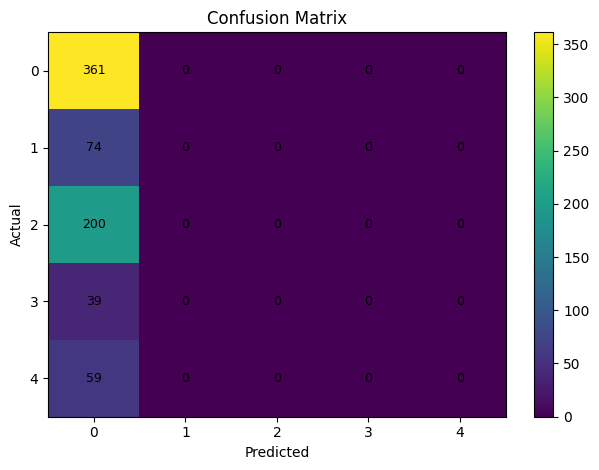

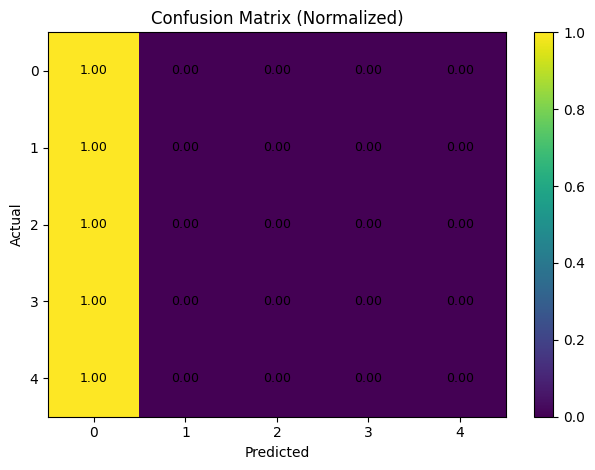

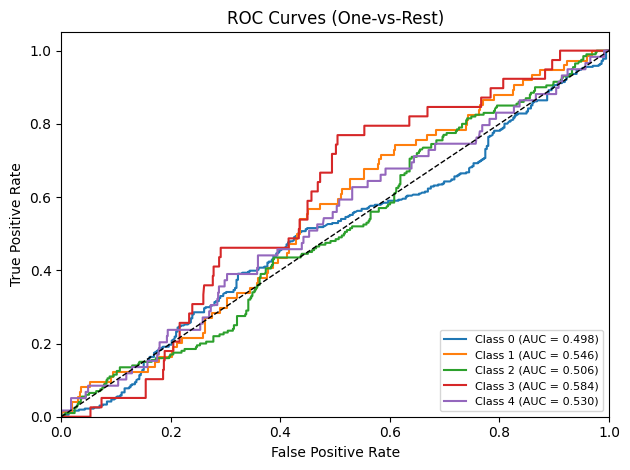

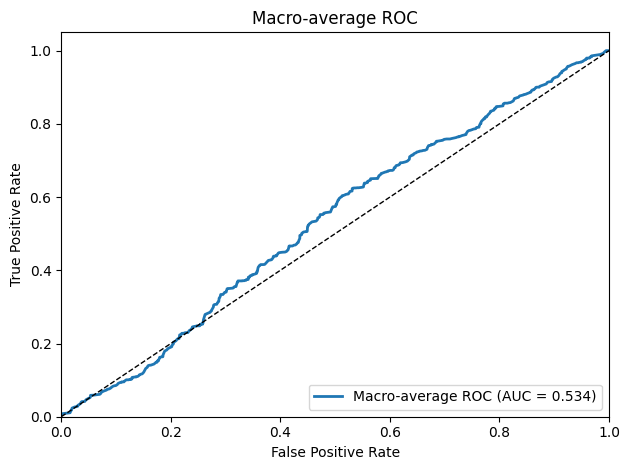

In [31]:
# ==========================================
# Evaluate B3@300: CM, Classification Report, ROC AUC
# ==========================================

import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -------- CONFIG (edit these) --------
MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_aug_reg.keras.keras"   #  improved model
VAL_DIR    = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"                    # folder with subfolders 0..4
IMG_SIZE   = (300, 300)                             # B3 input size
BATCH      = 32

# -------- Data --------
# Create first, capture class names, THEN cache/prefetch
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)
CLASS_NAMES = val_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

val_ds = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)

# -------- Load model --------
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# -------- Predict helper --------
def get_truth_and_preds(model, dataset):
    y_true, y_proba = [], []
    for x, y in dataset:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_proba.append(p)
    y_true  = np.vstack(y_true)                 # one-hot
    y_proba = np.vstack(y_proba)               # probabilities (softmax)
    y_true_int = np.argmax(y_true, axis=1)     # integer labels
    y_pred_int = np.argmax(y_proba, axis=1)    # predicted labels
    return y_true_int, y_pred_int, y_proba

y_true, y_pred, y_proba = get_truth_and_preds(model, val_ds)

# -------- Classification report (printed) --------
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

# -------- Confusion Matrix (plot) --------
def plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    plt.figure()
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    # annotations
    fmt = ".2f" if normalize else "d"
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center", fontsize=9)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plot_confusion_matrix(cm, CLASS_NAMES, normalize=False, title="Confusion Matrix")
plot_confusion_matrix(cm, CLASS_NAMES, normalize=True,  title="Confusion Matrix (Normalized)")

# -------- ROC AUC (one-vs-rest) --------
# Binarize true labels for OvR ROC
Y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))  # shape: [N, C]

# Per-class ROC + AUC
plt.figure()
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {CLASS_NAMES[c]} (AUC = {roc_auc:.3f})")
# Chance line
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Macro-average ROC (optional, nice summary line)
# Combine all FPR points across classes and interpolate TPRs to compute macro curve
all_fpr = np.unique(np.concatenate([roc_curve(Y_bin[:, c], y_proba[:, c])[0] for c in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Macro-average ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

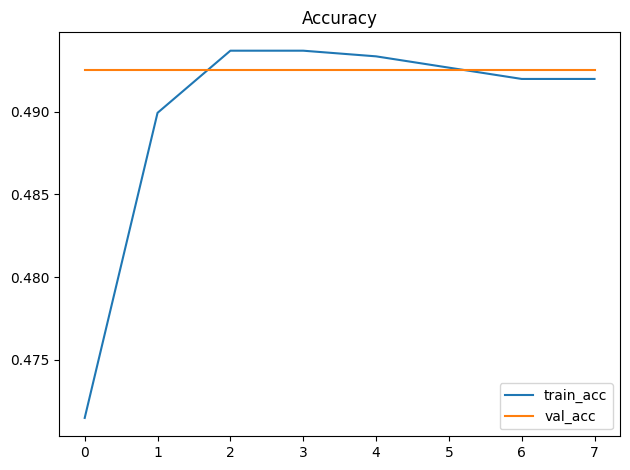

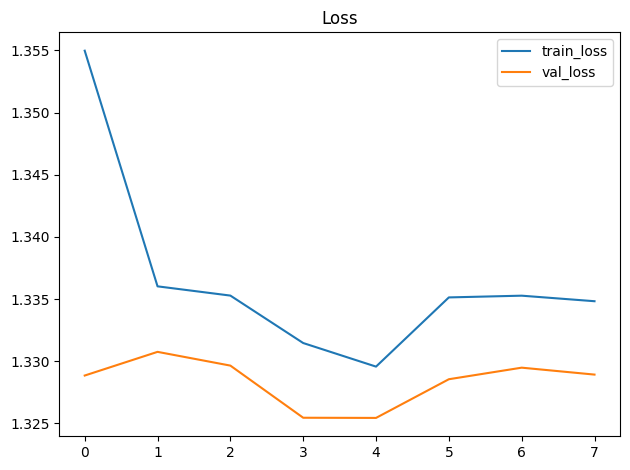

Macro ROC-AUC (val): 0.578


In [29]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Curves
plt.figure(); plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc"); plt.legend(); plt.title("Accuracy"); plt.tight_layout(); plt.show()

plt.figure(); plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss"); plt.legend(); plt.title("Loss"); plt.tight_layout(); plt.show()

# Macro ROC-AUC on val
y_true, y_proba = [], []
for x,y in val_ds:
    p = model.predict(x, verbose=0)
    y_true.append(y.numpy()); y_proba.append(p)
y_true  = np.vstack(y_true)
y_proba = np.vstack(y_proba)
y_true_int = np.argmax(y_true, axis=1)
Y_bin = label_binarize(y_true_int, classes=list(range(NUM_CLASSES)))
macro_auc = roc_auc_score(Y_bin, y_proba, average="macro", multi_class="ovr")
print(f"Macro ROC-AUC (val): {macro_auc:.3f}")

In [40]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3

IMG_SIZE = (300, 300)
NUM_CLASSES = 5
DROPOUT = 0.4

augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15, 0.15),
    layers.RandomContrast(0.25),
    layers.RandomBrightness(0.15),
], name="augmenter")

def build_b3_aug(num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=IMG_SIZE + (3,))
    x = layers.Rescaling(1./255)(inputs)
    x = augmenter(x)                        # on-GPU augmentations
    base = EfficientNetB3(include_top=False, weights="imagenet", input_tensor=x)
    for l in base.layers:
        if isinstance(l, layers.BatchNormalization):
            l.trainable = False
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(DROPOUT)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs)

model = build_b3_aug()

In [41]:
TRAIN_DIR = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/train"
VAL_DIR   = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"
BATCH = 32

train_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=True
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
).cache().prefetch(tf.data.AUTOTUNE)

train_ds = train_raw.cache().prefetch(tf.data.AUTOTUNE)

Found 2929 files belonging to 5 classes.
Found 733 files belonging to 5 classes.


In [42]:
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
from tensorflow.keras.optimizers import AdamW

steps_per_epoch = int(tf.data.experimental.cardinality(train_ds).numpy())
lr_schedule = CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=steps_per_epoch * 5,  # 5 epochs per cycle
    t_mul=2.0, m_mul=0.9, alpha=1e-6
)
opt = AdamW(learning_rate=lr_schedule, weight_decay=1e-5)

In [43]:
auc   = tf.keras.metrics.AUC(name="auc",   multi_label=True, num_labels=NUM_CLASSES, curve="ROC")
auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=NUM_CLASSES, curve="PR")

model.compile(
    optimizer=opt,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy", auc, auprc],
)

In [44]:

MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_aug_reg1.keras.keras"
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_PATH, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.4829 - auc: 0.5026 - auprc: 0.2036 - loss: 1.3599
Epoch 1: val_auc improved from -inf to 0.50000, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_aug_reg1.keras.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 116s 678ms/step - accuracy: 0.4830 - auc: 0.5025 - auprc: 0.2036 - loss: 1.3597 - val_accuracy: 0.4925 - val_auc: 0.5000 - val_auprc: 0.2000 - val_loss: 1.3267
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 511ms/step - accuracy: 0.4927 - auc: 0.4792 - auprc: 0.1901 - loss: 1.3400
Epoch 2: val_auc did not improve from 0.50000
92/92 ━━━━━━━━━━━━━━━━━━━━ 50s 547ms/step - accuracy: 0.4926 - auc: 0.4794 - auprc: 0.1902 - loss: 1.3399 - val_accuracy: 0.4925 - val_auc: 0.5000 - val_auprc: 0.2000 - val_loss: 1.3273
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.4965 - auc: 0.4872 - auprc: 0.1971 - loss: 1.3343
Epoch 3: val_auc improved from 0.50000 to 0.50050, savi

Found 733 files belonging to 5 classes.
=== Classification Report ===
              precision    recall  f1-score   support

           0      0.492     1.000     0.660       361
           1      0.000     0.000     0.000        74
           2      0.000     0.000     0.000       200
           3      0.000     0.000     0.000        39
           4      0.000     0.000     0.000        59

    accuracy                          0.492       733
   macro avg      0.098     0.200     0.132       733
weighted avg      0.243     0.492     0.325       733



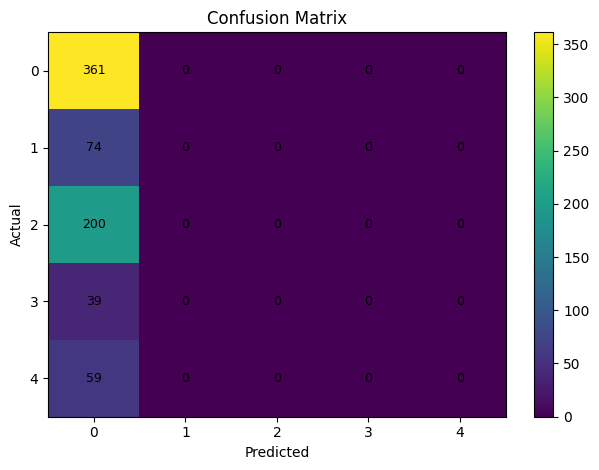

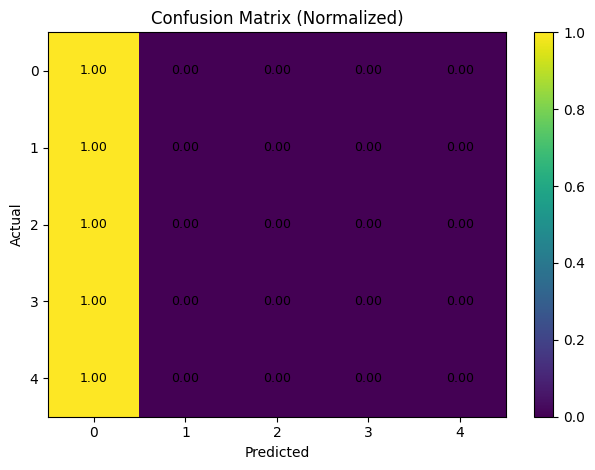

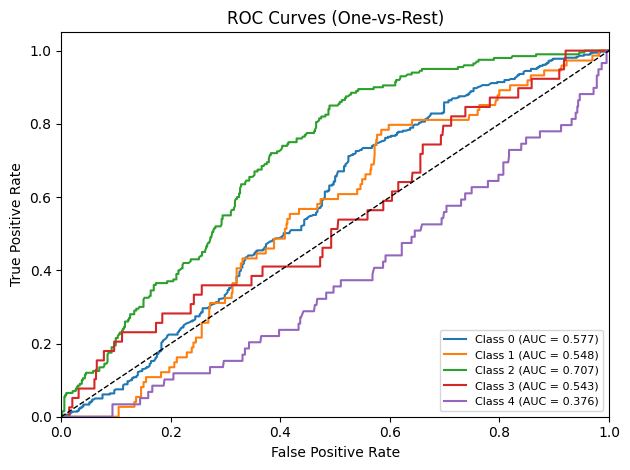

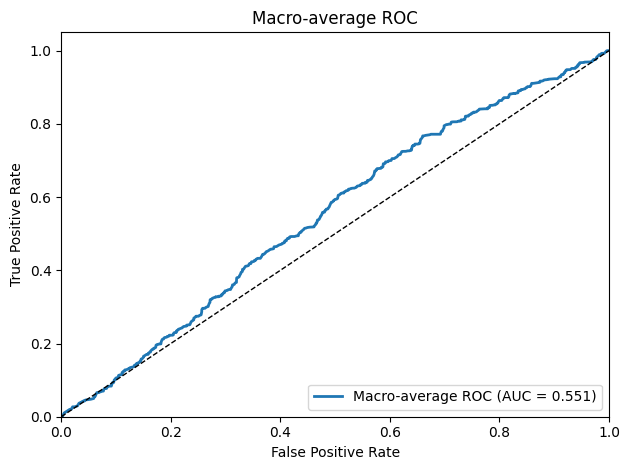

In [45]:
# ==========================================
# Evaluate B3@300: CM, Classification Report, ROC AUC
# ==========================================

import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# -------- CONFIG (edit these) --------
MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_aug_reg1.keras.keras"   #  improved model
VAL_DIR    = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/validation"                    # folder with subfolders 0..4
IMG_SIZE   = (300, 300)                             # B3 input size
BATCH      = 32

# -------- Data --------
# Create first, capture class names, THEN cache/prefetch
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)
CLASS_NAMES = val_ds_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

val_ds = val_ds_raw.cache().prefetch(tf.data.AUTOTUNE)

# -------- Load model --------
model = tf.keras.models.load_model(MODEL_PATH, compile=False)

# -------- Predict helper --------
def get_truth_and_preds(model, dataset):
    y_true, y_proba = [], []
    for x, y in dataset:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_proba.append(p)
    y_true  = np.vstack(y_true)                 # one-hot
    y_proba = np.vstack(y_proba)               # probabilities (softmax)
    y_true_int = np.argmax(y_true, axis=1)     # integer labels
    y_pred_int = np.argmax(y_proba, axis=1)    # predicted labels
    return y_true_int, y_pred_int, y_proba

y_true, y_pred, y_proba = get_truth_and_preds(model, val_ds)

# -------- Classification report (printed) --------
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3, zero_division=0))

# -------- Confusion Matrix (plot) --------
def plot_confusion_matrix(cm, class_names, normalize=False, title="Confusion Matrix"):
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    plt.figure()
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names)
    plt.yticks(tick_marks, class_names)
    # annotations
    fmt = ".2f" if normalize else "d"
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], fmt),
                     ha="center", va="center", fontsize=9)
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
plot_confusion_matrix(cm, CLASS_NAMES, normalize=False, title="Confusion Matrix")
plot_confusion_matrix(cm, CLASS_NAMES, normalize=True,  title="Confusion Matrix (Normalized)")

# -------- ROC AUC (one-vs-rest) --------
# Binarize true labels for OvR ROC
Y_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))  # shape: [N, C]

# Per-class ROC + AUC
plt.figure()
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {CLASS_NAMES[c]} (AUC = {roc_auc:.3f})")
# Chance line
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

# Macro-average ROC (optional, nice summary line)
# Combine all FPR points across classes and interpolate TPRs to compute macro curve
all_fpr = np.unique(np.concatenate([roc_curve(Y_bin[:, c], y_proba[:, c])[0] for c in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for c in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(Y_bin[:, c], y_proba[:, c])
    mean_tpr += np.interp(all_fpr, fpr, tpr)
mean_tpr /= NUM_CLASSES
macro_auc = auc(all_fpr, mean_tpr)

plt.figure()
plt.plot(all_fpr, mean_tpr, label=f"Macro-average ROC (AUC = {macro_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Macro-average ROC")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [46]:
# Evaluate
val_metrics = model.evaluate(val_ds, verbose=1)
print(f"Validation metrics: {val_metrics}")

# Plot curves
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc"); plt.legend(); plt.show()

ValueError: You must call `compile()` before using the model.

In [51]:
import tensorflow as tf

BASE_MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras"
IMG_SIZE = (300, 300)
NUM_CLASSES = 5

def load_base_model(path=BASE_MODEL_PATH):
    model = tf.keras.models.load_model(path, compile=False)
    # freeze BatchNorm for stability
    for l in model.layers:
        if isinstance(l, tf.keras.layers.BatchNormalization):
            l.trainable = False
    print("Loaded base model.")
    return model

In [52]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts
import numpy as np

def train_iteration(model, train_ds, val_ds, iteration_name, *,
                    lr_init=1e-4, epochs=8,
                    loss_fn="categorical_crossentropy",
                    class_weight=None):
    steps = int(tf.data.experimental.cardinality(train_ds).numpy())
    lr_schedule = CosineDecayRestarts(lr_init, steps*5, t_mul=2.0, m_mul=0.9, alpha=1e-6)
    opt = Adam(learning_rate=lr_schedule)
    auc = tf.keras.metrics.AUC(name="auc", multi_label=True, num_labels=NUM_CLASSES, curve="ROC")
    auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=NUM_CLASSES, curve="PR")
    model.compile(optimizer=opt, loss=loss_fn, metrics=["accuracy", auc, auprc])
    ckpt = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/"+f"{iteration_name}.keras"
    callbacks = [
        ModelCheckpoint(ckpt, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
        EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True, verbose=1),
    ]
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                     callbacks=callbacks, class_weight=class_weight, verbose=1)
    return model, hist

In [76]:
import tensorflow as tf
from tensorflow.keras import layers, models
# single, reusable augmenter
HEAVY_AUG = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.25),
], name="heavy_aug")
def add_heavy_augmentation(model: tf.keras.Model) -> tf.keras.Model:
    """
    Wrap `model` with an input->augment->model pipeline.
    Ensures the augmenter always sees a 4D batch tensor.
    """
    # Build a new input that matches the original model input shape (e.g., (300,300,3))
    in_shape = model.input_shape[1:]  # drop batch dim
    aug_input = layers.Input(shape=in_shape, name="aug_input")

    # IMPORTANT: call augmenter on the batch tensor; let Keras pass training=True internally during fit
    x = HEAVY_AUG(aug_input)

    # Feed augmented batch to the original model
    out = model(x)

    wrapped = models.Model(aug_input, out, name=f"{model.name}_aug")
    return wrapped

def replace_head_with_dropout(model, new_dropout=0.4):
    import tensorflow as tf
    from tensorflow.keras import layers, models

    # Find the last Dense layer (classifier)
    dense_layers = [l for l in model.layers if isinstance(l, layers.Dense)]
    if not dense_layers:
        raise ValueError("No Dense layer found — model might be wrapped (e.g., augmentation wrapper).")

    last_dense = dense_layers[-1]
    num_classes = last_dense.units

    # Find a good feature output (the tensor feeding the Dense layer)
    feature_tensor = last_dense.input

    # Build a new head: GAP (if not already), Dropout, Dense
    if not isinstance(model.layers[-2], layers.GlobalAveragePooling2D):
        # add GAP if last hidden tensor is 4D
        if len(feature_tensor.shape) == 4:
            x = layers.GlobalAveragePooling2D(name="gap_new")(feature_tensor)
        else:
            x = feature_tensor
    else:
        x = feature_tensor

    x = layers.Dropout(new_dropout, name=f"dropout_{new_dropout:.2f}")(x)
    new_logits = layers.Dense(num_classes, activation="softmax", name="classifier_new")(x)

    new_model = models.Model(model.input, new_logits, name=f"{model.name}_drop{new_dropout:.2f}")

    # Try to copy classifier weights if shape matches
    try:
        old_w = last_dense.get_weights()
        if new_model.get_layer("classifier_new").weights[0].shape == old_w[0].shape:
            new_model.get_layer("classifier_new").set_weights(old_w)
    except Exception:
        pass

    print(f"✅ Replaced head with Dropout={new_dropout}")
    return new_model

def replace_head_with_dropout_robust(model: tf.keras.Model,
                                     new_dropout: float = 0.4,
                                     num_classes: int = None) -> tf.keras.Model:
    """
    Replaces/creates a classifier head no matter if the model is wrapped.
    1) Try to find the last Dense layer anywhere inside (nested).
    2) If not found, cut at the last 4D feature map and build GAP -> Dropout -> Dense.

    If no Dense is found, you MUST pass num_classes.
    """
    # --- 1) Search nested layers for a Dense classifier
    flat_layers = [l for l in model._flatten_layers(include_self=False)]  # includes nested submodels
    dense_layers = [l for l in flat_layers if isinstance(l, layers.Dense)]

    if dense_layers:
        last_dense = dense_layers[-1]
        classes = last_dense.units if num_classes is None else num_classes
        feature_tensor = last_dense.input  # KerasTensor feeding the classifier

        # If the feature is still 4D, add GAP before dropout
        x = feature_tensor
        if len(x.shape) == 4:
            x = layers.GlobalAveragePooling2D(name="gap_new")(x)
        x = layers.Dropout(new_dropout, name=f"dropout_{new_dropout:.2f}")(x)
        logits = layers.Dense(classes, activation="softmax", name="classifier_new")(x)

        new_model = models.Model(model.input, logits, name=f"{model.name}_drop{new_dropout:.2f}")

        # try copy weights if shapes match
        try:
            old_w = last_dense.get_weights()
            if new_model.get_layer("classifier_new").weights[0].shape == old_w[0].shape:
                new_model.get_layer("classifier_new").set_weights(old_w)
        except Exception:
            pass

        print(f"Replaced existing Dense head with Dropout={new_dropout}")
        return new_model

    # --- 2) No Dense head found: cut at last 4D feature map and build a fresh head
    if num_classes is None:
        raise ValueError("No Dense layer found and num_classes=None. Provide num_classes to build a new head.")

    # Find the deepest 4D tensor in the graph (feature map)
    feat_layer = None
    # Walk reversed so we prefer deeper layers
    for l in reversed(flat_layers):
        out_shape = getattr(l, "output_shape", None)
        # Some layers have multiple outputs; handle that
        if out_shape is None:
            continue
        if isinstance(out_shape, (list, tuple)) and out_shape and hasattr(out_shape[0], "__len__"):
            # take first if it's a list of shapes
            try:
                rank = len(out_shape[0])
            except Exception:
                continue
        else:
            try:
                rank = len(out_shape)
            except Exception:
                continue
        if rank == 4:  # (B, H, W, C)
            feat_layer = l
            break

    if feat_layer is None:
        raise ValueError("Could not locate a 4D feature map to attach a new head to.")

    feature_tensor = feat_layer.output
    x = layers.GlobalAveragePooling2D(name="gap_new")(feature_tensor)
    x = layers.Dropout(new_dropout, name=f"dropout_{new_dropout:.2f}")(x)
    logits = layers.Dense(num_classes, activation="softmax", name="classifier_new")(x)

    new_model = models.Model(model.input, logits, name=f"{model.name}_drop{new_dropout:.2f}")
    print(f"✅ Built new head at last 4D feature map with Dropout={new_dropout}, classes={num_classes}")
    return new_model

def add_label_smoothing(loss_smooth=0.05):
    return tf.keras.losses.CategoricalCrossentropy(label_smoothing=loss_smooth)

In [80]:
import tensorflow as tf
from tensorflow.keras import layers, models

def replace_head_safe(model: tf.keras.Model, num_classes: int, new_dropout: float = 0.4) -> tf.keras.Model:
    """
    Cut at the deepest 4D layer using a proper submodel (Model(model.input, layer.output)),
    then attach GAP -> Dropout -> Dense. This avoids tensor mapping KeyError.
    """
    # 1) find deepest 4D layer in the current graph
    cut_layer = None
    for L in reversed(model.layers):
        try:
            shp = L.output_shape
        except Exception:
            continue
        if isinstance(shp, tuple) and len(shp) == 4:
            cut_layer = L
            break
    if cut_layer is None:
        raise ValueError("No 4D layer found to cut on. (Model may already end in 2D features.)")

    # 2) build a proper backbone submodel from the SAME input to the cut point
    backbone = models.Model(model.input, cut_layer.output, name=model.name + "_backbone")

    # 3) attach a fresh head
    x = layers.GlobalAveragePooling2D(name="gap_new")(backbone.output)
    x = layers.Dropout(new_dropout, name=f"dropout_{new_dropout:.2f}")(x)
    logits = layers.Dense(num_classes, activation="softmax", name="classifier_new")(x)

    new_model = models.Model(backbone.input, logits, name=model.name + "_new")
    return new_model
def add_heavy_augmentation_safe(model: tf.keras.Model) -> tf.keras.Model:
    aug = tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical"),
        layers.RandomRotation(0.20),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.25),
    ], name="heavy_aug")

    inputs = layers.Input(shape=model.input_shape[1:], name="aug_input")
    x = aug(inputs)                 # batch tensor, rank-4
    y = model(x)                    # call the whole model as a block
    wrapped = models.Model(inputs, y, name=model.name + "_aug")
    return wrapped

In [63]:
import tensorflow as tf
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

def ensure_compiled(model, train_ds=None, num_classes=5, lr_init=1e-4):
    """
    Re-compile the model if it isn't compiled.
    Call this before model.fit / model.evaluate / model.predict.
    """
    # Heuristic: compiled models have compiled_loss initialized after compile()
    needs_compile = (getattr(model, "compiled_loss", None) is None)

    if needs_compile:
        if train_ds is None:
            raise ValueError("Model needs compile but train_ds=None to compute steps_per_epoch.")

        steps = int(tf.data.experimental.cardinality(train_ds).numpy())
        if steps <= 0:
            raise ValueError("steps_per_epoch is 0. Check your dataset creation/batch size.")

        lr = CosineDecayRestarts(
            initial_learning_rate=lr_init,
            first_decay_steps=steps * 5,
            t_mul=2.0, m_mul=0.9, alpha=1e-6
        )
        auc   = tf.keras.metrics.AUC(name="auc",   multi_label=True, num_labels=num_classes, curve="ROC")
        auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=num_classes, curve="PR")

        model.compile(
            optimizer=tf.keras.optimizers.Adam(lr),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
            metrics=["accuracy", auc, auprc],
        )
        print ("Model COmpiled")
    return model

In [65]:
def compile_now(model, train_ds, num_classes=5, lr_init=1e-4):
    import tensorflow as tf
    from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

    steps = int(tf.data.experimental.cardinality(train_ds).numpy())
    if steps <= 0:
        raise ValueError("steps_per_epoch is 0. Build train_ds before compiling.")

    lr = CosineDecayRestarts(
        initial_learning_rate=lr_init,
        first_decay_steps=steps * 5,
        t_mul=2.0, m_mul=0.9, alpha=1e-6
    )

    auc   = tf.keras.metrics.AUC(name="auc",   multi_label=True, num_labels=num_classes, curve="ROC")
    auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=num_classes, curve="PR")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy", auc, auprc],
    )
    print(" Model compiled.")
    return model

In [84]:
# ---- Drop-in softmax focal loss (no addons needed) ----
import tensorflow as tf

def softmax_focal_loss(gamma=2.0, alpha=0.25, eps=1e-7):
    """
    Multiclass focal loss for softmax outputs.
    y_true: one-hot [B, C]
    y_pred: softmax probabilities [B, C]
    alpha : scalar or per-class vector (broadcastable to [B, C])
    """
    alpha_t = tf.constant(alpha, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

        # CE: -sum(y_true * log(y_pred), axis=-1)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)  # [B]
        # p_t: probability assigned to the true class
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)               # [B]
        # alpha per-sample (supports scalar or vector)
        if alpha_t.shape.rank == 0:
            alpha_b = tf.fill(tf.shape(p_t), alpha_t)               # scalar -> [B]
        else:
            # y_true @ alpha_vec -> [B]
            alpha_b = tf.reduce_sum(y_true * alpha_t, axis=-1)

        focal = tf.pow(1.0 - p_t, gamma)
        return alpha_b * focal * ce
    return loss

In [85]:
# Load datasets
IMG_SIZE = (300,300); BATCH=32
DATA_DIR="/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/"
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{DATA_DIR}/train", label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=True
).cache().prefetch(tf.data.AUTOTUNE)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    f"{DATA_DIR}/validation", label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
).cache().prefetch(tf.data.AUTOTUNE)

#  Baseline
base_model = load_base_model()
base_model = compile_now(base_model, train_ds, num_classes=len(CLASS_NAMES), lr_init=1e-4)
baseline_metrics = base_model.evaluate(val_ds, verbose=1)

# Iteration 1 — fine-tune with cosine schedule (no aug yet)
model1, hist1 = train_iteration(base_model, train_ds, val_ds, "iter1_lr_cosine")
metrics1 = model1.evaluate(val_ds, verbose=0)

# Iteration 2 — add augmentation + dropout tuning
#model2 = add_heavy_augmentation(model1)
model2 = add_heavy_augmentation_safe(model1)
#model2 = replace_head_with_dropout_robust(model2, new_dropout=0.4, num_classes=len(CLASS_NAMES))
model2 = replace_head_safe(model2, num_classes=len(CLASS_NAMES), new_dropout=0.4)
loss_aug = add_label_smoothing(0.05)
model2, hist2 = train_iteration(model2, train_ds, val_ds, "iter2_aug_dropout",
                                loss_fn=loss_aug)
metrics2 = model2.evaluate(val_ds, verbose=0)

# Iteration 3 — focal loss or class weights
#from tensorflow_addons.losses import SigmoidFocalCrossEntropy
#loss_focal = SigmoidFocalCrossEntropy(gamma=2.0)
loss_focal = softmax_focal_loss(gamma=2.0, alpha=0.25)

model3, hist3 = train_iteration(model2, train_ds, val_ds, "iter3_focal",
                                loss_fn=loss_focal)
metrics3 = model3.evaluate(val_ds, verbose=0)

Found 2929 files belonging to 5 classes.
Found 733 files belonging to 5 classes.
Loaded base model.
 Model compiled.
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 666ms/step - accuracy: 0.8165 - auc: 0.3151 - auprc: 0.2952 - loss: 0.7817
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 608ms/step - accuracy: 0.5839 - auc: 0.6784 - auprc: 0.3063 - loss: 1.1418
Epoch 1: val_auc improved from -inf to 0.76530, saving model to /content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/iter1_lr_cosine.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 132s 863ms/step - accuracy: 0.5839 - auc: 0.6786 - auprc: 0.3064 - loss: 1.1418 - val_accuracy: 0.6644 - val_auc: 0.7653 - val_auprc: 0.3760 - val_loss: 1.0063
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.6197 - auc: 0.7238 - auprc: 0.3348 - loss: 1.0450
Epoch 2: val_auc did not improve from 0.76530
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 129ms/step - accuracy: 0.6197 - auc: 0.7238 - auprc: 0.3348 - loss: 1.0451 - val_accuracy: 0.4270 - val_auc: 0.6544 - v

In [86]:
import pandas as pd

df = pd.DataFrame([
    ["Baseline", *baseline_metrics],
    ["LR Cosine", *metrics1],
    ["Aug + Dropout", *metrics2],
    ["Focal", *metrics3],
], columns=["Iteration", "Loss", "Accuracy", "AUC", "AUPRC"])

print(df)

       Iteration       Loss  Accuracy       AUC     AUPRC
0       Baseline   1.076928  0.680764  0.780296  0.390226
1      LR Cosine   1.006258  0.664393  0.765303  0.376009
2  Aug + Dropout  21.600643  0.129604  0.516586  0.209658
3          Focal   2.993020  0.141883  0.513658  0.211351


In [3]:
# ==========================================================
# Step 3: Data Augmentation & Regularization + Fine-tuning
# EfficientNetB3 @ 300x300
# ==========================================================
import os, numpy as np, tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers.schedules import CosineDecayRestarts

# --------------------
# CONFIG
# --------------------
SEED = 42
IMG_SIZE = (300, 300)
BATCH = 32
EPOCHS = 20
LABEL_SMOOTH = 0.05
HEAD_DROPOUT = 0.40      # set to None to keep original dropout
UNFREEZE_FRACTION = 0.5  # top 50%
DATA_DIR = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/images/"
BASE_MODEL_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/efficientnetb3_300_finetuned.keras"
OUT_PATH = "/content/drive/My Drive/capstone-3/milestone-4/aptos2019-blindness-detection1/b3_data_aug_finetuned.keras"

tf.random.set_seed(SEED)
AUTOTUNE = tf.data.AUTOTUNE

# --------------------
# DATASETS + AUGMENTATION (pipeline-safe)
# --------------------
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "validation")

# Build raw datasets
train_raw = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=True, seed=SEED
)
val_raw = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR, label_mode="categorical", image_size=IMG_SIZE, batch_size=BATCH, shuffle=False
)

CLASS_NAMES = train_raw.class_names
NUM_CLASSES = len(CLASS_NAMES)

# Augmenter (applied in dataset pipeline)
augmenter = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.20),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.25),
], name="augmenter")

train_ds = train_raw.map(lambda x,y: (augmenter(x, training=True), y),
                         num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
val_ds = val_raw.cache().prefetch(AUTOTUNE)

# --------------------
# OPTIONAL: Rebuild head to change dropout safely
# --------------------
def replace_head_safe(model: tf.keras.Model, num_classes: int, new_dropout: float) -> tf.keras.Model:
    """Cut at deepest 4D tensor -> GAP -> Dropout(new_dropout) -> Dense(num_classes, softmax)"""
    cut_layer = None
    for L in reversed(model.layers):
        try:
            shp = L.output_shape
            if isinstance(shp, tuple) and len(shp) == 4:
                cut_layer = L; break
        except Exception:
            continue
    if cut_layer is None:
        # model may already end in 2D features; just attach new head on last tensor
        feat = model.layers[-2].output if len(model.layers[-1].output_shape) == 2 else model.layers[-1].output
        x = feat
    else:
        backbone = models.Model(model.input, cut_layer.output, name=model.name + "_backbone")
        x = backbone.output
        model = backbone  # replace with backbone for new head

    if len(x.shape) == 4:
        x = layers.GlobalAveragePooling2D(name="gap_new")(x)
    x = layers.Dropout(new_dropout, name=f"dropout_{new_dropout:.2f}")(x)
    logits = layers.Dense(num_classes, activation="softmax", name="classifier_new")(x)
    return models.Model(model.input, logits, name=model.name + "_headupd")

# --------------------
# LOAD BASE MODEL
# --------------------
model = tf.keras.models.load_model(BASE_MODEL_PATH, compile=False)

# (Optional) update head dropout
if HEAD_DROPOUT is not None:
    model = replace_head_safe(model, NUM_CLASSES, HEAD_DROPOUT)

# --------------------
# FINE-TUNE SETTINGS
# --------------------
# Freeze BatchNorm layers (stability) and unfreeze top fraction of non-BN layers
non_bn_layers = [l for l in model.layers if not isinstance(l, tf.keras.layers.BatchNormalization)]
cut = int(len(non_bn_layers) * (1 - UNFREEZE_FRACTION))
for i, l in enumerate(non_bn_layers):
    l.trainable = (i >= cut)
for l in model.layers:
    if isinstance(l, tf.keras.layers.BatchNormalization):
        l.trainable = False

# Optimizer with CosineDecayRestarts
steps_per_epoch = int(tf.data.experimental.cardinality(train_ds).numpy())
lr = CosineDecayRestarts(
    initial_learning_rate=1e-4,
    first_decay_steps=steps_per_epoch * 5,    # ~5 epochs per cycle
    t_mul=2.0, m_mul=0.9, alpha=1e-6
)

auc   = tf.keras.metrics.AUC(name="auc",   multi_label=True, num_labels=NUM_CLASSES, curve="ROC")
auprc = tf.keras.metrics.AUC(name="auprc", multi_label=True, num_labels=NUM_CLASSES, curve="PR")

model.compile(
    optimizer=tf.keras.optimizers.Adam(lr),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=["accuracy", auc, auprc]
)

# --------------------
# TRAIN
# --------------------
callbacks = [
    ModelCheckpoint(OUT_PATH, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print(f" Saved fine-tuned model to: {OUT_PATH}")

Found 2929 files belonging to 5 classes.
Found 733 files belonging to 5 classes.


AttributeError: 'Dense' object has no attribute 'output_shape'